In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import display, Math, Latex
# from tqdm import tqdm
%matplotlib inline

/scratch/kg98/gchan/conda_envs/sir/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/scratch/kg98/gchan/conda_envs/sir/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/scratch/kg98/gchan/conda_envs/sir/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
import os

def save_paired_genes_to_csv(grouped, filename, chunk_size=10):
    """
    Saves clearance genes and associated risk genes to CSV files, aligning rows so that
    each clearance gene is repeated for each chunk of risk genes.

    :param grouped: Grouped pandas Series with clearance genes as the index and associated risk genes as values.
    :param clearance_filename: Name of the CSV file to save clearance genes.
    :param risk_filename: Name of the CSV file to save risk genes.
    :param chunk_size: Maximum number of risk genes per line in the output file.
    """

    # Ensure the directory exists before writing the file
    os.makedirs(os.path.dirname(filename), exist_ok=True)

    with open(filename, 'w') as f:
        n_jobs = 0
        for clear_gene, risk_genes in grouped.items():
            n_jobs += math.ceil(len(risk_genes) / chunk_size)
            for i in range(0, len(risk_genes), chunk_size):
                f.write(clear_gene + ',' + ','.join(risk_genes[i:i + chunk_size]) + '\n')
                

    print(f'Wrote {grouped.apply(len).sum()} gene pairs in {n_jobs} jobs to {filename}')

In [3]:
# Loading information from all sites for all gene pairs is very expensive
# Here we load only gene names, seeds, group correlations, and p-values
spatial_df = dd.read_csv('../results/250908_spatial/*.csv', assume_missing=True)
spatial_df = spatial_df.set_index(spatial_df['clearance gene'] + ' ' + spatial_df['risk gene'])
spatial_df = spatial_df.iloc[:, list(range(0, 4)) + [-1]]

# 100M rows takes 70 min on 55GB (6 columns)
# 100M rows takes 2.5 min on A40 (6 columns)
spatial_df = spatial_df.compute()
spatial_df_all = spatial_df.copy()

from statsmodels.stats.multitest import multipletests
spatial_df['p_spatial_fdr'] = multipletests(spatial_df['p_spatial'], method='fdr_bh')[1]
print(f"Significant pairs (spatial): {np.sum(spatial_df['p_spatial_fdr'] < 0.05)} / {spatial_df.shape[0]}")

Significant pairs (spatial): 125793 / 3541824


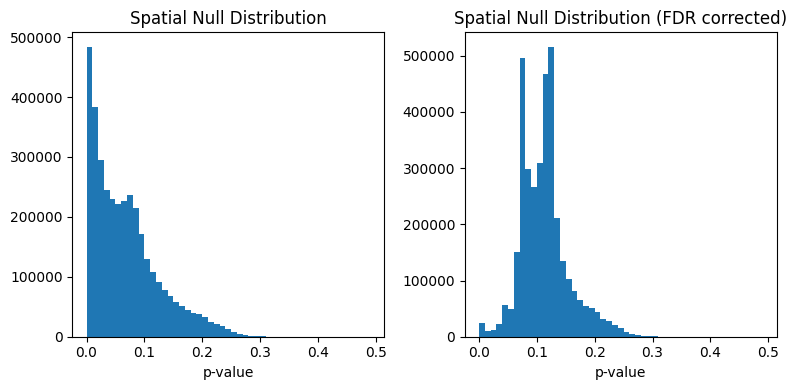

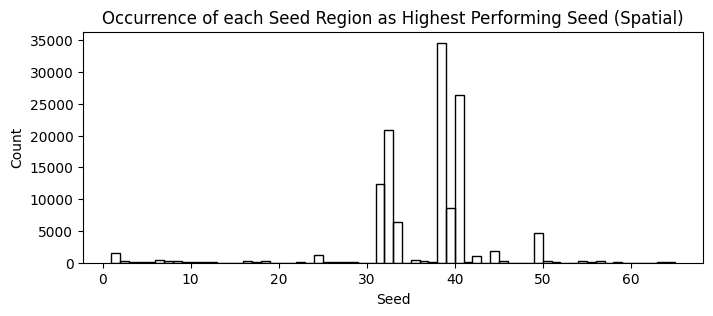

In [ ]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(spatial_df['p_spatial'], bins=np.arange(0, 0.5, 0.01))
plt.title('Spatial Null Distribution')
plt.xlabel('p-value')

plt.subplot(1, 2, 2)
plt.hist(spatial_df['p_spatial_fdr'], bins=np.arange(0, 0.5, 0.01))
plt.title('Spatial Null Distribution (FDR corrected)')
plt.xlabel('p-value')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
filtered_df = spatial_df[(spatial_df['p_spatial_fdr'] < 0.05)]
plt.hist(filtered_df['seed'], bins=range(1,66), edgecolor='black', fill=False)
plt.xlabel('Seed')
plt.ylabel('Count')
plt.title('Occurrence of each Seed Region as Highest Performing Seed (Spatial)')
plt.show()


In [ ]:
# save significant gene pairs for rerunning on null models
filtered_df = spatial_df[spatial_df['p_spatial_fdr'] < 0.05]
print(filtered_df.shape)

for seed in filtered_df['seed'].unique():
    grouped = filtered_df[filtered_df['seed'] == seed].groupby('clearance gene')['risk gene'].apply(list)
    save_paired_genes_to_csv(grouped, f'../data/gene_labels/250910_pairs/GO_spatial_{int(seed)}.csv', chunk_size=10)

(125793, 8)
Wrote 1242 gene pairs in 135 jobs to ../data/gene_labels/250910_pairs/GO_spatial_24.csv
Wrote 155 gene pairs in 23 jobs to ../data/gene_labels/250910_pairs/GO_spatial_41.csv
Wrote 2 gene pairs in 2 jobs to ../data/gene_labels/250910_pairs/GO_spatial_13.csv
Wrote 168 gene pairs in 24 jobs to ../data/gene_labels/250910_pairs/GO_spatial_25.csv
Wrote 8595 gene pairs in 930 jobs to ../data/gene_labels/250910_pairs/GO_spatial_39.csv
Wrote 34610 gene pairs in 3527 jobs to ../data/gene_labels/250910_pairs/GO_spatial_38.csv
Wrote 20825 gene pairs in 2150 jobs to ../data/gene_labels/250910_pairs/GO_spatial_32.csv
Wrote 6473 gene pairs in 711 jobs to ../data/gene_labels/250910_pairs/GO_spatial_33.csv
Wrote 85 gene pairs in 17 jobs to ../data/gene_labels/250910_pairs/GO_spatial_22.csv
Wrote 26464 gene pairs in 2713 jobs to ../data/gene_labels/250910_pairs/GO_spatial_40.csv
Wrote 150 gene pairs in 25 jobs to ../data/gene_labels/250910_pairs/GO_spatial_12.csv
Wrote 290 gene pairs in 37 j

In [4]:
# Load rewired null results
rewired_df = dd.read_csv('../results/250910_rewired/*.csv', assume_missing=True)
rewired_df = rewired_df.set_index(rewired_df['clearance gene'] + ' ' + rewired_df['risk gene'])
rewired_df = rewired_df.iloc[:, [-1]]

# 100M rows takes 70 min on 55GB (6 columns)
# 100M rows takes 2.5 min on A40 (6 columns)
rewired_df = rewired_df.compute()
rewired_df_all = rewired_df.copy()

# NOTE: multipletests does not work here because we have not tested all pairs on rewired nulls
# (i.e. m is incorrect). Join to spatial nulls and set missing pairs to non-significant

In [5]:
gene_df = spatial_df.join(rewired_df, how='left', rsuffix='_rewired')
gene_df['p_rewired'].fillna(1.0, inplace=True) # missing pairs are non-significant, needed for multipletests implementation

gene_df['p_spatial_fdr'] = multipletests(gene_df['p_spatial'], method='fdr_bh')[1]
gene_df['p_rewired_fdr'] = multipletests(gene_df['p_rewired'], method='fdr_bh')[1]

print(f"Significant pairs (spatial): {np.sum(gene_df['p_spatial_fdr'] < 0.05)} / {gene_df.shape[0]}")
print(f"Significant pairs (rewired): {np.sum(gene_df['p_rewired_fdr'] < 0.05)} / {gene_df[gene_df['p_rewired'] < 1].shape[0]}")

# display(gene_df[gene_df['p_rewired'] < 1])

Significant pairs (spatial): 125793 / 3541824
Significant pairs (rewired): 49085 / 125749


In [ ]:
# gene_df['pass_both'] = ((gene_df['p_spatial_fdr'] < 0.05) & (gene_df['p_rewired_fdr'] < 0.05)).astype(int)
# gene_df.reset_index(inplace=True)
# gene_df.drop(columns=['index', 'p_spatial', 'p_rewired'], inplace=True)
gene_df.to_csv('../../SIR_utils/enrichment/data/250910_gene_pair_pvalues.csv', index=False)
display(gene_df.head())

,risk gene,clearance gene,seed,correlation,p_spatial_fdr,p_rewired_fdr,pass_both
0,A1BG,ABCA2,40.0,0.404441,0.082302,1.0,0
1,A2M,ABCA2,40.0,0.378306,0.081658,1.0,0
2,A2ML1,ABCA2,39.0,0.312479,0.148274,1.0,0
3,A3GALT2,ABCA2,39.0,0.361337,0.100766,1.0,0
4,A4GALT,ABCA2,38.0,0.377037,0.093800,1.0,0


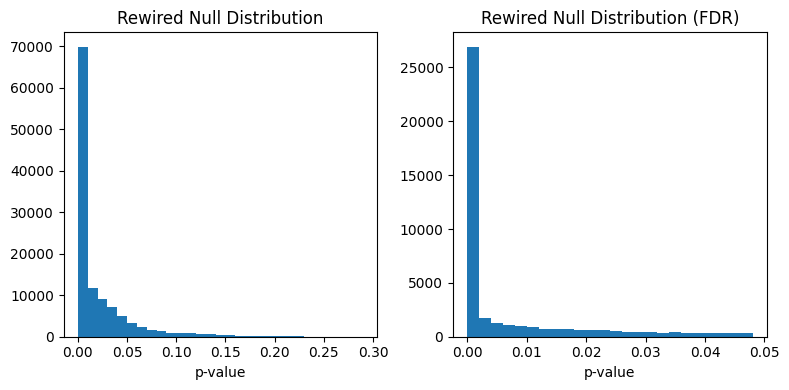

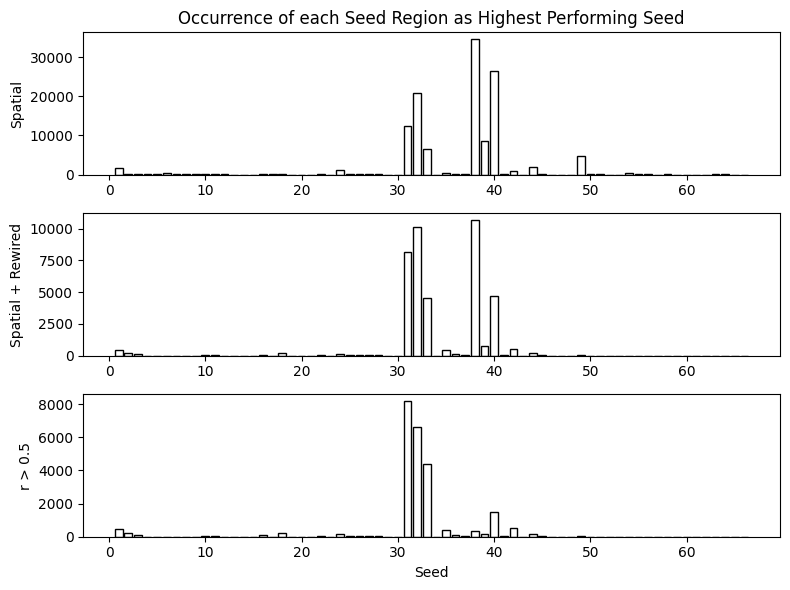

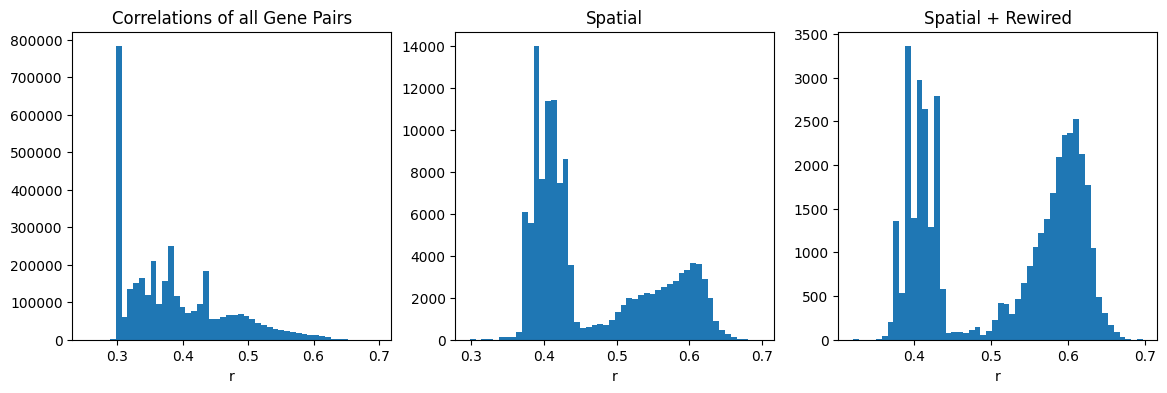

In [101]:
# rewired null distribution
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(gene_df['p_rewired'], bins=np.arange(0, 0.3, 0.01))
plt.title('Rewired Null Distribution')
plt.xlabel('p-value')
plt.subplot(1, 2, 2)
plt.hist(gene_df['p_rewired_fdr'], bins=np.arange(0, 0.05, 0.002))
plt.title('Rewired Null Distribution (FDR)')
plt.xlabel('p-value')
plt.tight_layout()
plt.show()


filtered_df = gene_df[(gene_df['p_spatial_fdr'] < 0.05) & (gene_df['p_rewired_fdr'] < 0.05)]
filtered_df_spatial = gene_df[(gene_df['p_spatial_fdr'] < 0.05)]
filtered_df_corr = filtered_df[filtered_df['correlation'] > 0.5]

# seed occurrences
plt.figure(figsize=(8, 6))
plt.subplot(3, 1, 1)
plt.bar(
    range(1, 67),
    [filtered_df_spatial['seed'].value_counts().get(i, 0) for i in range(1, 67)],
    align='center',
    edgecolor='black',
    fill=False,
)
plt.title('Occurrence of each Seed Region as Highest Performing Seed')
plt.ylabel('Spatial')
plt.subplot(3, 1, 2)
plt.bar(
    range(1, 67),
    [filtered_df['seed'].value_counts().get(i, 0) for i in range(1, 67)],
    align='center',
    edgecolor='black',
    fill=False,
)
plt.ylabel('Spatial + Rewired')
plt.subplot(3, 1, 3)
plt.bar(
    range(1, 67),
    [filtered_df_corr['seed'].value_counts().get(i, 0) for i in range(1, 67)],
    align='center',
    edgecolor='black',
    fill=False,
)
plt.ylabel('r > 0.5')
plt.xlabel('Seed')
plt.tight_layout()
plt.show()

# correlation distribution
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.hist(gene_df['correlation'], bins=50)
plt.xlabel('r')
plt.title('Correlations of all Gene Pairs')
plt.subplot(1, 3, 2)
plt.hist(filtered_df_spatial['correlation'], bins=50)
plt.xlabel('r')
plt.title('Spatial')
plt.subplot(1, 3, 3)
plt.hist(filtered_df['correlation'], bins=50)
plt.xlabel('r')
plt.title('Spatial + Rewired')
plt.show()

In [98]:
out_counts = filtered_df_corr['risk gene'].value_counts()
out_counts = out_counts[out_counts > 5]
# print(out_counts.index)
np.savetxt('clearance_gene_gt1.csv', out_counts.index, fmt='%s')

95
8474
UBE2D1     3907
VMP1       3769
TRIM5      2385
UNC13D     1445
BCL10      1213
           ... 
RNF135        1
LAMTOR1       1
RNASET2       1
RAMP3         1
SYVN1         1
Name: clearance gene, Length: 95, dtype: int64
IRF9        16
HNRNPC      12
MBLAC2      12
GHR         12
NHLRC1      12
            ..
HYLS1        1
IFIT2        1
IFT20        1
SECISBP2     1
STAM         1
Name: risk gene, Length: 8474, dtype: int64


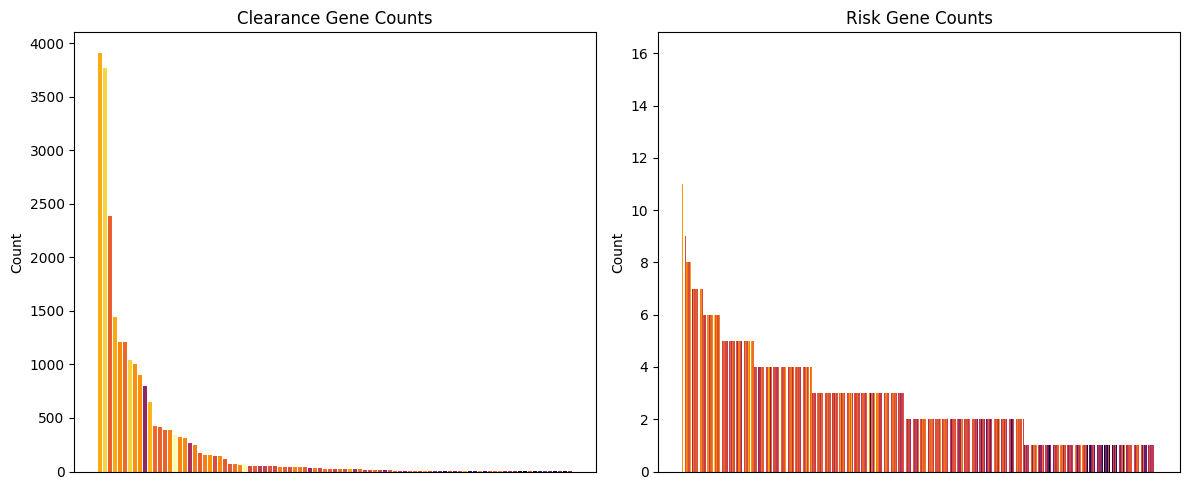

In [80]:
print(filtered_df_corr['clearance gene'].nunique())
print(filtered_df_corr['risk gene'].nunique())
print(filtered_df_corr['clearance gene'].value_counts())
print(filtered_df_corr['risk gene'].value_counts())

plt.figure(figsize=(12, 5))

# Get max correlation for each clearance gene and risk gene
clearance_corr = filtered_df_corr.groupby('clearance gene')['correlation'].max()
risk_corr = filtered_df_corr.groupby('risk gene')['correlation'].max()

# Normalize correlations to [0, 1] for colormap
clearance_norm = (clearance_corr - clearance_corr.min()) / (clearance_corr.max() - clearance_corr.min())
risk_norm = (risk_corr - risk_corr.min()) / (risk_corr.max() - risk_corr.min())

plt.subplot(1, 2, 1)
vc_clear = filtered_df_corr['clearance gene'].value_counts()
clear_colors = clearance_norm[vc_clear.index].map(plt.cm.inferno)
plt.bar(vc_clear.index, vc_clear.values, color=clear_colors)
plt.title('Clearance Gene Counts')
plt.ylabel('Count')
plt.xticks([], [])  # Remove x axis text

plt.subplot(1, 2, 2)
vc_risk = filtered_df_corr['risk gene'].value_counts()
risk_colors = risk_norm[vc_risk.index].map(plt.cm.inferno)
plt.bar(vc_risk.index, vc_risk.values, color=risk_colors)
plt.title('Risk Gene Counts')
plt.ylabel('Count')
plt.xticks([], [])  # Remove x axis text

plt.tight_layout()
plt.show()